In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!gdown 1Sm8UZ-JZBjw-xBCUb3_-AmTlwPGd6RBi

Downloading...
From: https://drive.google.com/uc?id=1Sm8UZ-JZBjw-xBCUb3_-AmTlwPGd6RBi
To: /content/IMDB Dataset.csv
100% 66.2M/66.2M [00:00<00:00, 97.8MB/s]


In [ ]:
!pip install unidecode
!pip install contractions
!pip install tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00





# **Import Library**

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader,Dataset
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import unidecode
import string
import contractions
from collections import defaultdict
import math
import matplotlib.pyplot as plt
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import html
from sklearn.metrics import f1_score, precision_score, recall_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# **Load Dataset**

In [ ]:
df = pd.read_csv('./IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [ ]:
print(f'Number of Null value: {df.isnull().sum().values.sum()}')
print(f'Number of positive Sentiment {sum(df['sentiment'] == 'positive')}')
print(f'Number of negative Sentiment {sum(df['sentiment'] == 'negative')}')

Number of Null value: 0
Number of positive Sentiment 25000
Number of negative Sentiment 25000


In [ ]:
X = df['review'].values
y = df['sentiment'].values
y = [1 if label == 'positive' else 0 for label in y]
n_classes = len(set(y))
n_classes

2

In [ ]:
# @title
pos_count = 0
neg_count = 0
for label in y:
  if label == 1:
    pos_count +=1
  else:
    neg_count +=1
print(pos_count,neg_count)

25000 25000


# **Text Preprocessing & Tokenization**

In [ ]:
def text_clean(text):

    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = unidecode.unidecode(text)
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'([.,!?])', r' \1 ', text)
    text = re.sub(r'[^a-z0-9\s.,!?\'-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_clean = [text_clean(text) for text in X]

tokenizer = Tokenizer(BPE(unk_token="<UNK>"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=25000,
    min_frequency=2,
    special_tokens=["<PAD>", "<UNK>"]
)

tokenizer.train_from_iterator(X_clean, trainer)
vocab_size = tokenizer.get_vocab_size()
pad_token_id = tokenizer.token_to_id("<PAD>")
print(f"Vocab Size: {vocab_size}, PAD ID: {pad_token_id}")
tokenizer_path = os.path.join("/content/drive/MyDrive/Colab Notebooks/ĐATH-IMDB", "tokenizer.json")
tokenizer.save(tokenizer_path)

Vocab Size: 25000, PAD ID: 0


# **Text Vectorization**

In [ ]:
seq_lens = [len(tokenizer.encode(x).ids) for x in X_clean]

# Xem thống kê
print(f"Độ dài trung bình: {np.mean(seq_lens)}")
print(f"Độ dài tối đa: {np.max(seq_lens)}")
print(f"Độ dài bao phủ 95% dữ liệu: {np.percentile(seq_lens, 95)}")
print(f"Độ dài bao phủ 99% dữ liệu: {np.percentile(seq_lens, 99)}")

Độ dài trung bình: 273.01138
Độ dài tối đa: 2972
Độ dài bao phủ 95% dữ liệu: 700.0
Độ dài bao phủ 99% dữ liệu: 1065.010000000002


In [ ]:
max_seq_len = 512
tokenizer.enable_padding(pad_id=pad_token_id, pad_token="<PAD>", length=max_seq_len)
tokenizer.enable_truncation(max_length=max_seq_len)
X_vec = [e.ids for e in tokenizer.encode_batch(X_clean)]
X_vec = np.array(X_vec)

In [ ]:
def filter_empty_rows(X, y, pad_id):

    non_pad_counts = np.count_nonzero(X != pad_id, axis=1)
    print(f"Number of only padding text: {np.sum(non_pad_counts==0)}")
    keep_mask = non_pad_counts > 0
    num_deleted = len(X) - keep_mask.sum()
    if num_deleted > 0:
        X_filtered = X[keep_mask]
        y_filtered = y[keep_mask]
        return X_filtered, y_filtered
    else:
        return X, y
X_vec, y = filter_empty_rows(X_vec,y, pad_token_id)

Number of only padding text: 0


# IMDB Dataset

In [ ]:
class ImdbDataset(Dataset):
  def __init__(self,X,y):
    self.data = X
    self.label = y
  def __len__(self):
    return len(self.label)
  def __getitem__(self, idx):
    return torch.tensor(self.data[idx],dtype=torch.long),torch.tensor(self.label[idx],dtype=torch.long)

# **LSTM**

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(LSTMClassifier,self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2)
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        output = self.fc(dropped)
        return output

# **Transformer model**

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,embed_dim,num_heads,dropout):
    super().__init__()
    self.attn = nn.MultiheadAttention(embed_dim,num_heads,dropout,batch_first=True)
    self.norm1 = nn.LayerNorm(embed_dim)
    self.dropout = nn.Dropout(dropout)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.ffwd = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
  def forward(self,x,src_key_padding_mask=None):
    skip = x
    x,_ = self.attn(x,x,x, key_padding_mask=src_key_padding_mask) #output, weight
    x = self.norm1(skip+self.dropout(x))
    skip = x
    x = self.ffwd(x)
    x = self.norm2(skip+self.dropout(x))
    return x

class TransformerEncoder(nn.Module):
  def __init__(self,vocab_size,max_seq_len,embed_dim,num_heads,num_blocks,dropout,n_classes, pad_idx):
    super().__init__()
    self.pad_idx = pad_idx
    self.embed_matrix = nn.Embedding(num_embeddings=vocab_size,embedding_dim=embed_dim, padding_idx=pad_idx)

    self.register_buffer('positional_encoding', self._create_pos_encoding(max_seq_len, embed_dim))
    self.dropout = nn.Dropout(dropout)
    self.encoder_layers = nn.ModuleList([])
    for i in range(num_blocks):
      self.encoder_layers.append(EncoderBlock(embed_dim,num_heads,dropout))
    self.ffwd = nn.Linear(embed_dim,embed_dim*2)
    self.relu = nn.ReLU()
    self.out = nn.Linear(embed_dim*2,n_classes)

  def _create_pos_encoding(self, max_len, embed_dim):
    pe = torch.zeros(max_len, embed_dim)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe.unsqueeze(0)

  def forward(self,x):
    # BxS
    padding_mask = (x == self.pad_idx)
    seq_len = x.size(1)
    x = self.embed_matrix(x)* math.sqrt(self.embed_matrix.embedding_dim)
    x = x + self.positional_encoding[:, :seq_len, :]
    x = self.dropout(x)
    for layer in self.encoder_layers:
      x = layer(x, src_key_padding_mask=padding_mask)
    mask_float = (~padding_mask).float().unsqueeze(-1)
    x = x*mask_float
    sum_embedings = torch.sum(x, dim=1)
    count_tokens = torch.sum(mask_float, dim=1).clamp(min=1)
    mean_pooling = sum_embedings/ count_tokens
    x = self.ffwd(mean_pooling)
    x = self.relu(x)
    return self.out(x)





# **Training**

In [ ]:
def evaluate(model, val_loader, criterion, device):
    model.eval()
    batch_val_loss = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            batch_val_loss.append(criterion(outputs, labels).item())
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    epoch_val_loss = sum(batch_val_loss) / len(batch_val_loss)
    val_acc = np.mean(np.array(all_preds) == np.array(all_targets))
    val_f1 = f1_score(all_targets, all_preds, average='binary')
    val_precision = precision_score(all_targets, all_preds, average='binary')
    val_recall = recall_score(all_targets, all_preds, average='binary')

    return epoch_val_loss, val_acc, val_f1, val_precision, val_recall

def fit(model, criterion, optimizer, train_loader, val_loader, num_epochs, device, save_path="/content/drive/MyDrive/Colab Notebooks/IMDBdataset"):
    epoch_train_loss = []
    epoch_train_acc = []
    epoch_val_loss = []
    epoch_val_acc = []

    best_val_loss = 1000
    early_stop_count = 0
    patience = 10

    for epoch in range(num_epochs):
        model.train()
        batch_train_loss = []
        batch_train_acc = []
        count = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()

            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.sum(torch.argmax(outputs, dim=1) == labels).item())
            count += len(labels)

        train_loss = sum(batch_train_loss) / len(batch_train_loss)
        train_acc = sum(batch_train_acc) / count
        val_loss, val_acc, val_f1, val_prec, val_rec = evaluate(model, val_loader, criterion, device)
        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)
        epoch_val_loss.append(val_loss)
        epoch_val_acc.append(val_acc)
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        print(f'  Train Acc:  {train_acc:.4f} | Val Acc:  {val_acc:.4f}')
        print(f'  Val F1:     {val_f1:.4f}   | Val P:    {val_prec:.4f} | Val R: {val_rec:.4f}')
        print("-" * 50)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_count = 0
            torch.save(model.state_dict(), os.path.join(save_path, 'best_model.pt'))
        else:
            early_stop_count += 1

        if early_stop_count == patience:
            break

    model.load_state_dict(torch.load(os.path.join(save_path, 'best_model.pt'), map_location=device))

    return epoch_train_loss, epoch_train_acc, epoch_val_loss, epoch_val_acc

# **LSTM**

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 32
embed_dim = 128
hidden_dim = 128
num_layers = 2
dropout = 0.2
num_epochs = 8
X_train, X_test, y_train, y_test = train_test_split(vectorize_corpus, y, test_size=0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1)
train_dataset = ImdbDataset(X_train,y_train)
val_dataset = ImdbDataset(X_val, y_val)
test_dataset = ImdbDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

lstm_model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.9)

epoch_train_loss, epoch_train_acc, epoch_val_loss, epoch_val_acc = fit(
    lstm_model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, device)


In [ ]:
device = 'cuda' if torch.cuda.is_available else 'cpu'
batch_size = 64
embed_dim = 256
num_heads = 4
num_blocks = 2
dropout=0.1
num_epochs = 10
learning_rate = 5e-4
X_train,X_test,y_train,y_test = train_test_split(X_vec,y,test_size=0.2)
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size=0.1)
train_dataset = ImdbDataset(X_train,y_train)
val_dataset = ImdbDataset(X_val,y_val)
test_dataset = ImdbDataset(X_test,y_test)
train_loader = DataLoader(train_dataset,batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size)
test_loader = DataLoader(test_dataset,batch_size)
model = TransformerEncoder(vocab_size,max_seq_len,embed_dim,num_heads,num_blocks,dropout,n_classes,pad_token_id).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.9)
epoch_train_loss,epoch_train_acc,epoch_val_loss,epoch_val_acc = fit(model,criterion,optimizer,
                                                                    train_loader,val_loader,num_epochs,device)



Epoch 1/10:
  Train Loss: 0.4738 | Val Loss: 0.3879
  Train Acc:  0.7692 | Val Acc:  0.8330
  Val F1:     0.8322   | Val P:    0.8381 | Val R: 0.8263
--------------------------------------------------
Epoch 2/10:
  Train Loss: 0.3817 | Val Loss: 0.3448
  Train Acc:  0.8298 | Val Acc:  0.8330
  Val F1:     0.8280   | Val P:    0.8553 | Val R: 0.8024
--------------------------------------------------
Epoch 3/10:
  Train Loss: 0.3541 | Val Loss: 0.3234
  Train Acc:  0.8457 | Val Acc:  0.8550
  Val F1:     0.8528   | Val P:    0.8678 | Val R: 0.8383
--------------------------------------------------
Epoch 4/10:
  Train Loss: 0.3268 | Val Loss: 0.2988
  Train Acc:  0.8590 | Val Acc:  0.8720
  Val F1:     0.8764   | Val P:    0.8486 | Val R: 0.9062
--------------------------------------------------
Epoch 5/10:
  Train Loss: 0.3050 | Val Loss: 0.2983
  Train Acc:  0.8674 | Val Acc:  0.8700
  Val F1:     0.8752   | Val P:    0.8429 | Val R: 0.9102
----------------------------------------------

In [ ]:
total_epoch_train_loss, total_epoch_train_acc, total_epoch_val_loss, total_epoch_val_acc = [], [], [], []
total_epoch_train_loss += epoch_train_loss
total_epoch_train_acc += epoch_train_acc
total_epoch_val_loss += epoch_val_loss
total_epoch_val_acc += epoch_val_acc

In [ ]:
model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/Colab Notebooks/ĐATH-FINAL/ĐATH-IMDB Transformer",'best_model.pt'),weights_only=True))
epoch_train_loss,epoch_train_acc,epoch_val_loss,epoch_val_acc = fit(model,criterion,optimizer,
                                                                    train_loader,val_loader,num_epochs,device)
total_epoch_train_loss += epoch_train_loss
total_epoch_train_acc += epoch_train_acc
total_epoch_val_loss += epoch_val_loss
total_epoch_val_acc += epoch_val_acc

Epoch 1/10:
  Train Loss: 0.2566 | Val Loss: 0.2763
  Train Acc:  0.8935 | Val Acc:  0.8780
  Val F1:     0.8737   | Val P:    0.9075 | Val R: 0.8423
--------------------------------------------------
Epoch 2/10:
  Train Loss: 0.2467 | Val Loss: 0.3182
  Train Acc:  0.8985 | Val Acc:  0.8690
  Val F1:     0.8770   | Val P:    0.8280 | Val R: 0.9321
--------------------------------------------------
Epoch 3/10:
  Train Loss: 0.2385 | Val Loss: 0.2575
  Train Acc:  0.9038 | Val Acc:  0.8900
  Val F1:     0.8924   | Val P:    0.8752 | Val R: 0.9102
--------------------------------------------------
Epoch 4/10:
  Train Loss: 0.2285 | Val Loss: 0.2663
  Train Acc:  0.9077 | Val Acc:  0.8920
  Val F1:     0.8935   | Val P:    0.8830 | Val R: 0.9042
--------------------------------------------------
Epoch 5/10:
  Train Loss: 0.2198 | Val Loss: 0.2722
  Train Acc:  0.9112 | Val Acc:  0.8860
  Val F1:     0.8844   | Val P:    0.8990 | Val R: 0.8703
----------------------------------------------

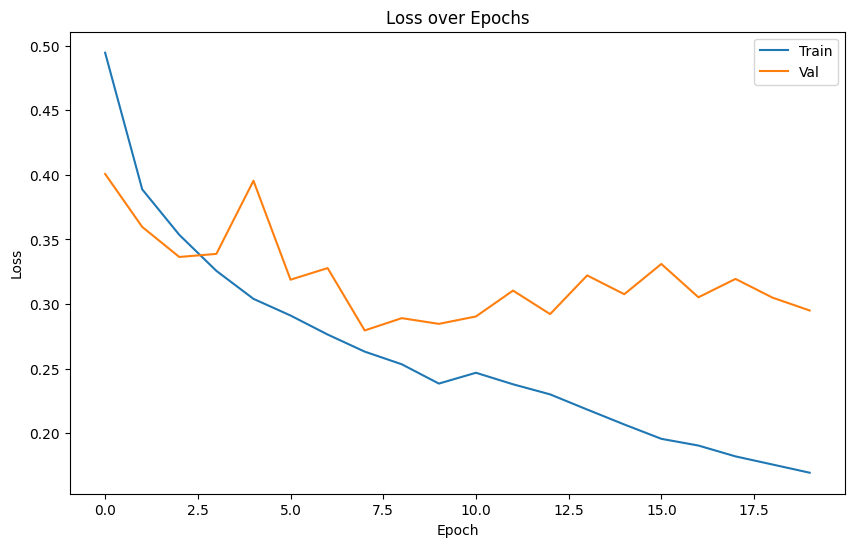

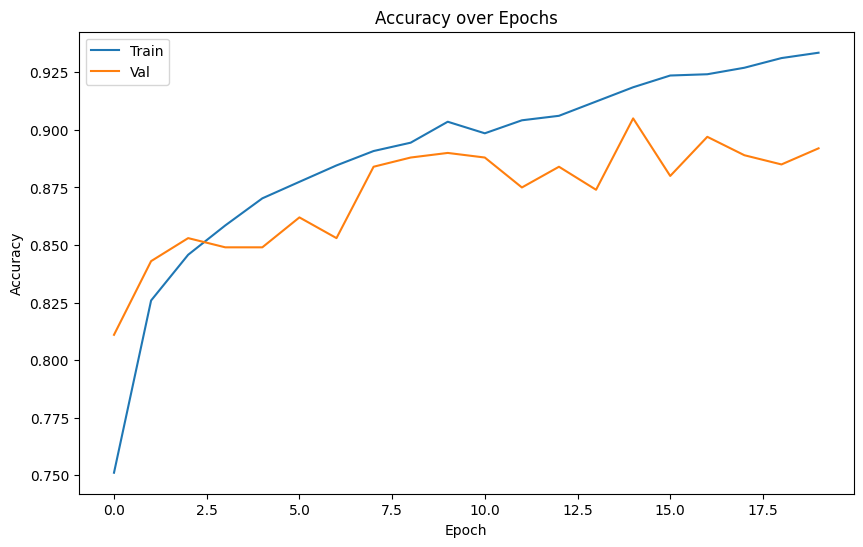

In [ ]:
def plot(epoch_train_loss,epoch_train_acc,epoch_val_loss,epoch_val_acc):
  plt.figure(figsize=(10,6))
  x_axis = range(len(epoch_train_loss))
  plt.plot(x_axis,epoch_train_loss,label="Train")
  plt.plot(x_axis,epoch_val_loss,label="Val")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss over Epochs')
  plt.legend()
  plt.show()
  plt.figure(figsize=(10,6))
  plt.plot(x_axis,epoch_train_acc,label="Train")
  plt.plot(x_axis,epoch_val_acc,label="Val")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Accuracy over Epochs')
  plt.legend()
  plt.show()
plot(total_epoch_train_loss,total_epoch_train_acc,total_epoch_val_loss,total_epoch_val_acc)

In [ ]:
device = 'cuda' if torch.cuda.is_available else 'cpu'
batch_size = 64
embed_dim = 256
num_heads = 4
num_blocks = 2
dropout=0.1
num_epochs = 10
learning_rate = 5e-4
X_train,X_test,y_train,y_test = train_test_split(X_vec,y,test_size=0.2)
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size=0.1)
train_dataset = ImdbDataset(X_train,y_train)
val_dataset = ImdbDataset(X_val,y_val)
test_dataset = ImdbDataset(X_test,y_test)
train_loader = DataLoader(train_dataset,batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size)
test_loader = DataLoader(test_dataset,batch_size)
criterion = nn.CrossEntropyLoss()

In [ ]:
lstm_model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_layers, dropout).to(device)
lstm_model.load_state_dict(torch.load('./lstm.pt', weights_only=True))
train_loss, train_acc, train_f1, train_precision, train_recall = evaluate(lstm_model,train_loader,criterion,device)
print('=======Train======')
print(f'Train Loss: {train_loss}')
print(f'Train Accuracy: {train_acc}')
print(f'Train F1 Score: {train_f1}')
print(f'Train Precision: {train_precision}')
print(f'Train Recall: {train_recall}\n')
print('=======Validation========')
val_loss, val_acc, val_f1, val_precision, val_recall = evaluate(lstm_model,val_loader,criterion,device)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_acc}')
print(f'Validation F1 Score: {val_f1}')
print(f'Validation Precision: {val_precision}')
print(f'Validation Recall: {val_recall}\n')
print('=======Test========')
test_loss, test_acc, test_f1, test_precision, test_recall = evaluate(lstm_model,test_loader,criterion,device)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')
print(f'Test F1 Score: {test_f1}')
print(f'Test Precision: {test_precision}')
print(f'Test Recall: {test_recall}')

In [ ]:
model = TransformerEncoder(vocab_size,max_seq_len,embed_dim,num_heads,num_blocks,dropout,n_classes,pad_token_id).to(device)
model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/Colab Notebooks/ĐATH-FINAL/ĐATH-IMDB Transformer",'best_model.pt'),weights_only=True))
train_loss, train_acc, train_f1, train_precision, train_recall = evaluate(model,train_loader,criterion,device)
print('=======Train======')
print(f'Train Loss: {train_loss}')
print(f'Train Accuracy: {train_acc}')
print(f'Train F1 Score: {train_f1}')
print(f'Train Precision: {train_precision}')
print(f'Train Recall: {train_recall}\n')
print('=======Validation========')
val_loss, val_acc, val_f1, val_precision, val_recall = evaluate(model,val_loader,criterion,device)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_acc}')
print(f'Validation Accuracy: {val_acc}')
print(f'Validation F1 Score: {val_f1}')
print(f'Validation Precision: {val_precision}')
print(f'Validation Recall: {val_recall}\n')
print('=======Test========')
test_loss, test_acc, test_f1, test_precision, test_recall = evaluate(model,test_loader,criterion,device)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')
print(f'Test F1 Score: {test_f1}')
print(f'Test Precision: {test_precision}')
print(f'Test Recall: {test_recall}')

=======Train======
Train Loss: 0.20946760309934617
Train Accuracy: 0.915575
Train F1 Score: 0.9168983930900411
Train Precision: 0.900522041763341
Train Recall: 0.9338813975637876

=======Validation========
Validation Loss: 0.18343785824254155
Validation Accuracy: 0.934
Validation Accuracy: 0.934
Validation F1 Score: 0.9336016096579477
Validation Precision: 0.9206349206349206
Validation Recall: 0.9469387755102041

=======Test========
Test Loss: 0.21124647539241095
Test Accuracy: 0.9138888888888889
Test F1 Score: 0.9168365704474729
Test Precision: 0.8978562421185372
Test Recall: 0.9366367024775268


# **Inference**

In [ ]:
model = TransformerEncoder(vocab_size,max_seq_len,embed_dim,num_heads,num_blocks,dropout,n_classes,pad_token_id).to(device)
model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/Colab Notebooks/ĐATH-IMDB",'best_model.pt'),weights_only=True))
idx_2_label = {0: 'Negative', 1: 'Positive'}

def predict_sentiment(text):
    model.eval()
    clean_text = text_clean(text)
    encoded = tokenizer.encode(clean_text)
    tensor_in = torch.tensor(encoded.ids, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor_in)
        probs = torch.softmax(output, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    return idx_2_label[pred_idx.item()], conf.item()

# Test thử vài câu
reviews = [
    'I expected so much more. The pacing was slow and the dialogue felt unnatural.',
    'I didn’t expect much from this movie at first, but it completely surprised me. The story is heartfelt without feeling cheesy, and the character development is incredibly satisfying. The actors have amazing chemistry, and every emotional moment lands perfectly. The pacing is steady, the jokes work, and the final act ties everything together beautifully. This is the kind of film that stays with you long after the credits roll.',
    'I expected so much more based on the trailer, but the film completely failed to deliver. The story drags, the jokes fall flat, and the entire middle section feels like filler. The performances are wooden, especially the supporting cast. By the time the big reveal came, I had already lost interest. This is one of those movies that sounds better on paper than it plays on screen.',
    'There’s nothing inherently wrong with this film, but there’s nothing especially remarkable about it either. The cast does a decent job and the production value is better than expected, yet the story follows familiar beats and never tries anything new. It’s the kind of movie you might enjoy on a quiet evening, but it probably won’t leave much of an impression afterward.',
    'Terribly executed from start to finish. The premise had potential, but everything else fell apart. The acting is stiff, the pacing is erratic, and the final act is laughably bad. I rarely give harsh reviews, but this film left me frustrated and disappointed. I wouldn’t recommend it to anyone.'

]

print("\n--- INFERENCE RESULTS ---")
for r in reviews:
    label, conf = predict_sentiment(r)
    print(f"Review: {r}\n -> Predicted: {label} ({conf:.2%})\n")



--- INFERENCE RESULTS ---
Review: I expected so much more. The pacing was slow and the dialogue felt unnatural.
 -> Predicted: Negative (98.45%)

Review: I didn’t expect much from this movie at first, but it completely surprised me. The story is heartfelt without feeling cheesy, and the character development is incredibly satisfying. The actors have amazing chemistry, and every emotional moment lands perfectly. The pacing is steady, the jokes work, and the final act ties everything together beautifully. This is the kind of film that stays with you long after the credits roll.
 -> Predicted: Positive (99.25%)

Review: I expected so much more based on the trailer, but the film completely failed to deliver. The story drags, the jokes fall flat, and the entire middle section feels like filler. The performances are wooden, especially the supporting cast. By the time the big reveal came, I had already lost interest. This is one of those movies that sounds better on paper than it plays on sc